# Benchmark of expression level

This notebook benchmark the expression level with other methods

In [2]:
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

## 1. Replicates (rep1 vs. rep2)

In [3]:
m = pd.read_csv("results/matrix/K562.s4U_0uM_180min.umi_based.mrUMI.csv", index_col=0)
m1 = m[filter(lambda x: x.startswith("20220719_K562_3."), m.columns)]
m2 = m[filter(lambda x: x.startswith("20220729_K562_3."), m.columns)]
print(m1.shape, m2.shape)

(15505, 58) (15505, 70)


In [4]:
s1 = m1.sum(axis=1) # counts
s2 = m2.sum(axis=1)
xs = s1 * 1e4 / sum(s1) # TP10K
ys = s2 * 1e4 / sum(s2)
r = pearsonr(xs, ys)[0]
print("Pearson r =", r)

Pearson r = 0.9684888866475513


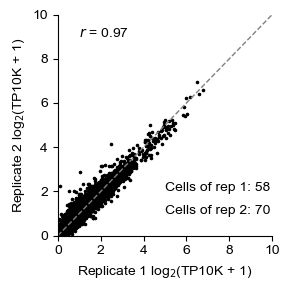

In [5]:
lim = 10
step = 2
plt.figure(figsize=(3, 3))
plt.scatter(np.log2(xs + 1), np.log2(ys + 1), marker=".", s=10, color="black")
# sns.kdeplot(x=xs, y=ys, fill=True, cmap='Blues', cbar=False, alpha=1, zorder=2)
plt.plot([0, lim], [0, lim], lw=1, ls="--", color="grey")
plt.text(1, lim * 0.9, "$\it{r}$ = %.2f" % r)
plt.text(lim * 0.5, lim * 0.2, "Cells of rep 1: %d" % len(m1.columns))
plt.text(lim * 0.5, lim * 0.1, "Cells of rep 2: %d" % len(m2.columns))
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.xticks(np.arange(0, lim + 1, step))
plt.yticks(np.arange(0, lim + 1, step))
plt.xlabel("Replicate 1 log$_2$(TP10K + 1)")
plt.ylabel("Replicate 2 log$_2$(TP10K + 1)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
# plt.savefig("figures/correlation.K562.run1_vs_run2.pdf")
plt.show()
plt.close()

## 2. Treatment (control vs. experiment)

In [6]:
! wc -l results/pseudobulk/K562.s4U_0uM_180min.2TC.gene_based.filelist.txt
! wc -l results/pseudobulk/K562.s4U_50uM_180min.2TC.gene_based.filelist.txt

190 results/pseudobulk/K562.s4U_0uM_180min.2TC.gene_based.filelist.txt
105 results/pseudobulk/K562.s4U_50uM_180min.2TC.gene_based.filelist.txt


--------------------------------------------------------------------------------
gene
Pearson r = 0.9808191870282871


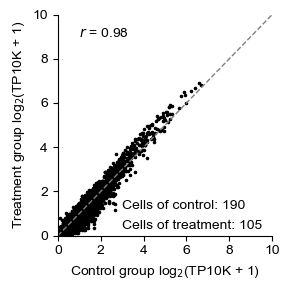

--------------------------------------------------------------------------------
transcript
Pearson r = 0.9803152854942285


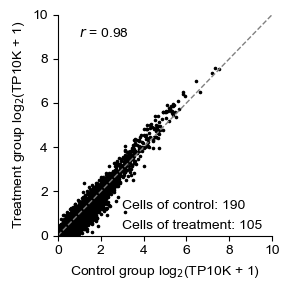

In [11]:
for base in ["gene", "transcript"]:
    print("-" * 80)
    print(base)
    d1 = pd.read_csv("results/pseudobulk/K562.s4U_0uM_180min.2TC.%s_based.annotated.csv" % base, index_col=0)
    d2 = pd.read_csv("results/pseudobulk/K562.s4U_50uM_180min.2TC.%s_based.annotated.csv" % base, index_col=0)
    s1 = d1["TP10K"]
    s1.name = "s4U_0uM_180min"
    s2 = d2["TP10K"]
    s2.name = "s4U_50uM_180min"
    m = pd.concat([s1, s2], axis=1).fillna(0)
    xs, ys = m["s4U_0uM_180min"], m["s4U_50uM_180min"]
    r = np.corrcoef(xs, ys)[0][1]
    print("Pearson r =", r)
    
    lim, step = 10, 2
    plt.figure(figsize=(3, 3))
    plt.scatter(np.log2(xs + 1), np.log2(ys + 1), marker=".", s=10, color="black")
    plt.plot([0, lim], [0, lim], lw=1, ls="--", color="grey")
    plt.text(1, lim * 0.9, "$\it{r}$ = %.2f" % r)
    plt.text(lim * 0.3, lim * 0.12, "Cells of control: 190")
    plt.text(lim * 0.3, lim * 0.03, "Cells of treatment: 105")
    plt.xlim(0, lim)
    plt.ylim(0, lim)
    plt.xticks(np.arange(0, lim + 1, step))
    plt.yticks(np.arange(0, lim + 1, step))
    plt.xlabel("Control group log$_2$(TP10K + 1)")
    plt.ylabel("Treatment group log$_2$(TP10K + 1)")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig("figures/correlation.K562.0uM_vs_50uM.%s_based.pdf" % base)
    plt.show()
    plt.close()

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

#d1 = pd.read_csv("reports/transcript_based/K562.control_cells.min_read_2_min_tc_1.annotated.tsv", sep="\t", index_col=0)
#d2 = pd.read_csv("reports/transcript_based/K562.treatment_cells.min_read_2_min_tc_1.annotated.tsv", sep="\t", index_col=0)

Name: gene
Peason r: 0.9810288747083167
Spearman r: 0.8725343839349982


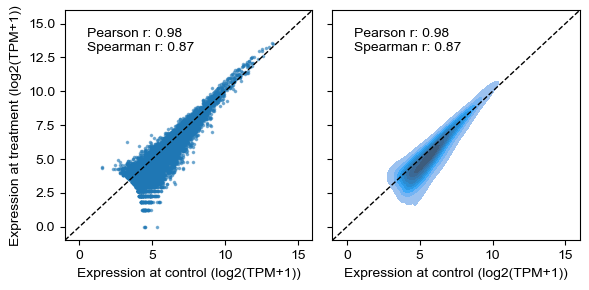

Name: transcript
Peason r: 0.9799935827803842
Spearman r: 0.8000669102056945


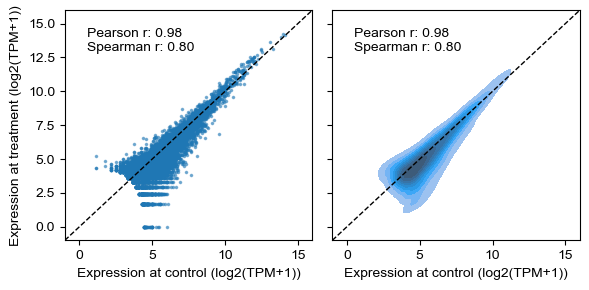

In [16]:
for base in ["gene", "transcript"]:
    print("Name:", base)
    
    d1 = pd.read_csv("results/pseudobulk/K562.s4U_0uM_180min.1TC.%s_based.annotated.csv" % base, index_col=0)
    d2 = pd.read_csv("results/pseudobulk/K562.s4U_50uM_180min.1TC.%s_based.annotated.csv" % base, index_col=0)
    
    s1 = d1["TPM"]
    s1.name = "control"
    s2 = d2["TPM"]
    s2.name = "treatment"
    d = pd.concat([s1, s2], axis=1).fillna(0)
    d = d[d.mean(axis=1) >= 10]
    r1 = d.corr(method="pearson").values[0][1]
    print("Peason r:", r1)
    r2 = d.corr(method="spearman").values[0][1]
    print("Spearman r:", r2)
    
    xs = np.log2(1 + d["control"])
    ys = np.log2(1 + d["treatment"])
    
    fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)
    
    plt.sca(axs[0])
    plt.scatter(xs, ys, marker=".", s=10, alpha=0.5)
    plt.xlabel("Expression at control (log2(TPM+1))")
    plt.ylabel("Expression at treatment (log2(TPM+1))")
    plt.xlim(-1, 16)
    plt.ylim(-1, 16)
    plt.plot([-1, 16], [-1, 16], lw=1, color="black", ls="--")
    plt.text(0.5, 14, "Pearson r: %.2f" % r1)
    plt.text(0.5, 13, "Spearman r: %.2f" % r2)
    
    
    plt.sca(axs[1])
    sns.kdeplot(x=xs, y=ys, fill=True)
    plt.xlabel("Expression at control (log2(TPM+1))")
    plt.ylabel("Expression at treatment (log2(TPM+1))")
    plt.plot([-1, 16], [-1, 16], lw=1, color="black", ls="--")
    plt.text(0.5, 14, "Pearson r: %.2f" % r1)
    plt.text(0.5, 13, "Spearman r: %.2f" % r2)
    
    plt.tight_layout()
    plt.savefig("figures/expression_correlation.control_vs_treatment.K562.%s_based.pdf" % base)
    plt.show()
    plt.close()